# Meta-strategy (σ) analysis — does the PSRO mixture help, and how to improve it?

The belief-activation loop keeps a **mixture σ over three strategies** —
`coherence` (+1), `contradiction` (−1), `semantic`/cosine (0) — and updates it
each batch by **multiplicative weights on a surprisal signal** `|y_judged − field|`
(`psro.PSROLoop._meta_reward` / `_update_mixture`). The Router fuses the agents'
scores **weighted by σ** to pick `/infer` seeds.

This notebook answers, with plots:
1. **Does σ actually learn?** (trajectory, per-agent meta-rewards, surprisal)
2. **Does it beat the trivial baselines?** (σ-fusion vs uniform vs single-strategy)
3. **Can we do better?** prototype a **quality-aligned meta-objective** (σ ∝ each
   strategy's downstream usefulness) vs the current surprisal-only σ.

> **Data choice.** We use synthetic *antipodal-topic* beliefs so the judge emits
> real **contradictions** (negative labels) — without them the surprisal signal is
> degenerate and σ never moves. (This is the same reason a cosine judge flatlines
> σ on coherence-only text; see the TGN notebook.)

## Setup

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if (ROOT/"notebooks").is_dir() and str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import logging; logging.getLogger("multi_agent.runner").setLevel(logging.ERROR)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from multi_agent.config import MultiAgentConfig
from multi_agent.runner import Trainer
from multi_agent.router import Router
from multi_agent.utils.notebook import make_synthetic_batches, make_cosine_judge
print("ok")

ok


## Data + train the activation loop

Antipodal topics → within-topic pairs are coherent (+), opposite-sign pairs are
contradictory (−). We train one PSRO run and record σ each step.

In [2]:
EMB, SEED = 64, 0
batches = make_synthetic_batches(n_nodes=160, n_batches=16, n_topic_pairs=4, emb_dim=EMB, noise=0.25, seed=1)
judge = make_cosine_judge(batches)
topic, emb = {}, {}
for b in batches:
    for i,t in zip(b.ids,b.texts): topic[i]=t.split("[topic ")[1].rstrip("]")
    for i,e in zip(b.ids,b.embs): emb[i]=np.asarray(e,np.float32)
nodes=list(topic)

tr = Trainer(MultiAgentConfig(emb_dim=EMB, num_agents=2, k=8, judge_budget_per_batch=60,
                              use_tgn=False, seed=SEED), judge)
for b in batches: tr.step(b)
hist = tr.history
agents = [a.agent_id for a in tr.population.agents]
print("agents:", agents)
print("final σ:", {k: round(v,3) for k,v in tr.loop.sigma.items()})

agents: ['agent_0', 'agent_1', 'cosine']
final σ: {'agent_0': 0.592, 'agent_1': 0.205, 'cosine': 0.204}


## 1. Does σ learn? — trajectory, meta-rewards, surprisal

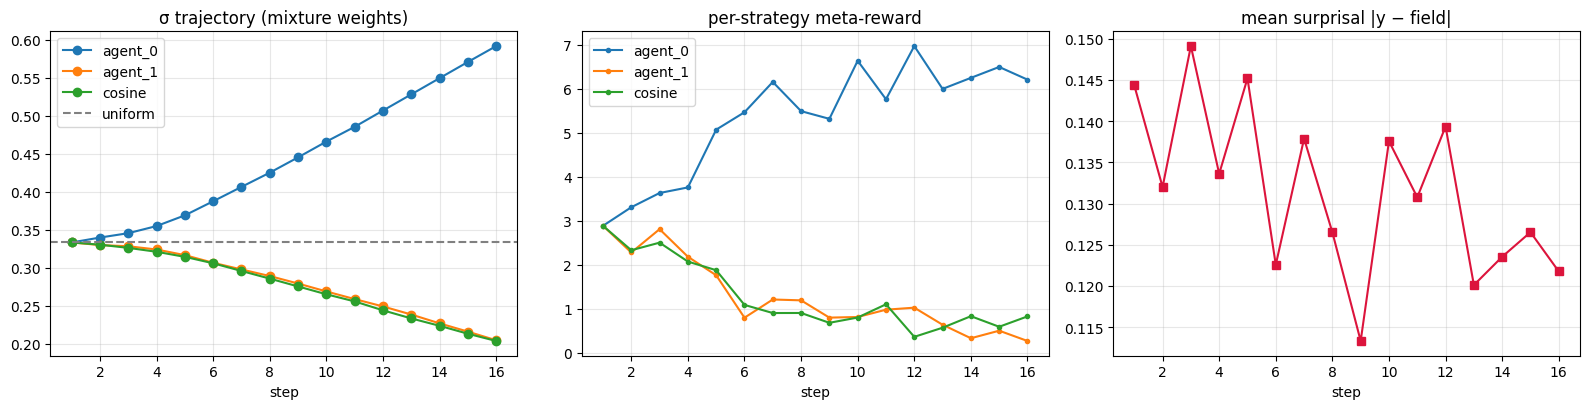

σ moved from uniform


In [3]:
sig_df = pd.DataFrame([s.sigma for s in hist])
mr_df  = pd.DataFrame([s.meta_rewards for s in hist])
steps  = [s.step for s in hist]
fig, ax = plt.subplots(1, 3, figsize=(16,4.2))
for a in sig_df.columns: ax[0].plot(steps, sig_df[a], marker='o', label=a)
ax[0].axhline(1/len(sig_df.columns), ls='--', c='gray', label='uniform')
ax[0].set_title("σ trajectory (mixture weights)"); ax[0].set_xlabel("step"); ax[0].legend(); ax[0].grid(alpha=.3)
for a in mr_df.columns: ax[1].plot(steps, mr_df[a], marker='.', label=a)
ax[1].set_title("per-strategy meta-reward"); ax[1].set_xlabel("step"); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(steps, [s.mean_surprisal for s in hist], marker='s', color='crimson')
ax[2].set_title("mean surprisal |y − field|"); ax[2].set_xlabel("step"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("σ moved from uniform" if abs(sig_df.iloc[-1].max()-1/len(sig_df.columns))>0.03 else "σ stayed ~uniform")

## 2. Regret vs the best fixed strategy

If the meta-loop is working, its cumulative meta-reward should track the
**best-fixed-arm in hindsight** (low regret). High flat regret ⇒ σ isn't earning
its keep.

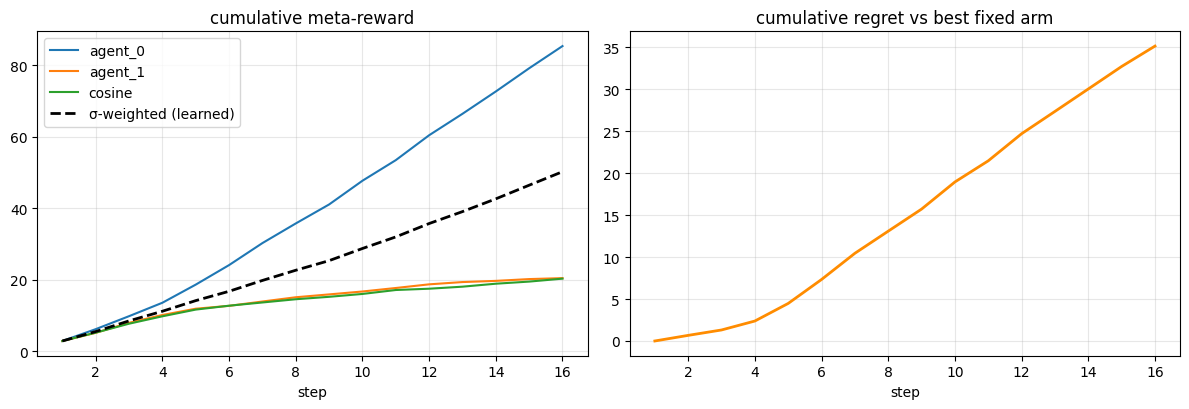

final regret = 35.166  (≈0 good; large ⇒ a fixed arm would've beaten σ)


In [4]:
arms = list(mr_df.columns)
cum_arm = mr_df.cumsum()                       # cumulative reward per fixed arm
learned = (sig_df[arms].shift(1).fillna(1/len(arms)) * mr_df).sum(axis=1).cumsum()  # σ-weighted
best_fixed = cum_arm.max(axis=1)
regret = best_fixed - learned
fig, ax = plt.subplots(1,2, figsize=(12,4.2))
for a in arms: ax[0].plot(steps, cum_arm[a], label=a)
ax[0].plot(steps, learned, 'k--', lw=2, label='σ-weighted (learned)')
ax[0].set_title("cumulative meta-reward"); ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_xlabel("step")
ax[1].plot(steps, regret, color='darkorange', lw=2)
ax[1].set_title("cumulative regret vs best fixed arm"); ax[1].grid(alpha=.3); ax[1].set_xlabel("step")
plt.tight_layout(); plt.show()
print(f"final regret = {regret.iloc[-1]:.3f}  (≈0 good; large ⇒ a fixed arm would've beaten σ)")

## 3. Does learned σ beat the trivial baselines on *seed quality*?

The Router fuses agent scores by σ to pick seeds. We compare fusion modes on
**seed Recall@k** (gold = same-topic beliefs). `single:<agent>` isolates one
strategy; `uniform` ignores σ.

,Recall@10
uniform,0.335
σ (learned),0.177
single:coherence,0.112
single:contradiction,0.108
single:cosine,0.642


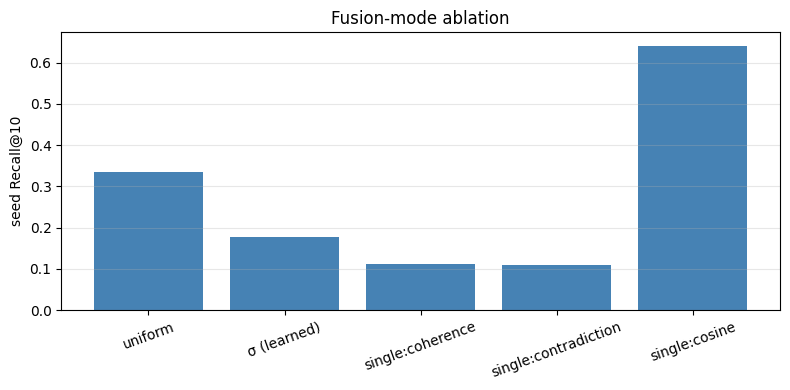

In [5]:
snap, w = tr.to_snapshot(session_id="m")
def router(fusion="sigma", sigma_override=None):
    r = Router.from_snapshot(snap, w, fusion=fusion)
    if sigma_override is not None: r.sigma = dict(sigma_override)
    return r
rng = np.random.default_rng(0)
def recall_at_k(r, k=10, nq=60):
    qs = rng.choice(nodes, nq, replace=False); out=[]
    for q in qs:
        gold = {n for n in nodes if n!=q and topic[n]==topic[q]}
        if not gold: continue
        ranked = [b for b,_ in r.rank(emb[q], k=k+1) if b!=q][:k]
        out.append(len(set(ranked)&gold)/min(k,len(gold)))
    return float(np.mean(out))

modes = {"uniform": router("uniform"),
         "σ (learned)": router("sigma"),
         "single:coherence": router("single:"+agents[0]),
         "single:contradiction": router("single:"+agents[1]),
         "single:cosine": router("single:cosine")}
rec = {name: recall_at_k(r, 10) for name,r in modes.items()}
display(pd.Series(rec, name="Recall@10").round(3).to_frame())
plt.figure(figsize=(8,4)); plt.bar(rec.keys(), rec.values(), color="steelblue")
plt.ylabel("seed Recall@10"); plt.title("Fusion-mode ablation"); plt.xticks(rotation=20); plt.grid(axis='y',alpha=.3); plt.tight_layout(); plt.show()

## 4. Improvement — a **quality-aligned** meta-objective

The current σ is driven by *surprisal* (how wrong the graph was), a proxy that
need not track downstream usefulness. We prototype a meta-objective that weights
each strategy by its **measured seed quality** (standalone Recall@10) instead, and
inject it back into the Router's σ:

`σ_quality[a] ∝ Recall@10(single:a)`

then compare seed Recall@10 under **uniform vs surprisal-σ vs quality-σ**.

per-arm standalone Recall@10: {'agent_0': 0.117, 'agent_1': 0.102, 'cosine': 0.667}
quality-aligned σ: {'agent_0': 0.132, 'agent_1': 0.115, 'cosine': 0.753}


,Recall@10
uniform,0.327
surprisal-σ (current),0.187
quality-σ (proposed),0.645


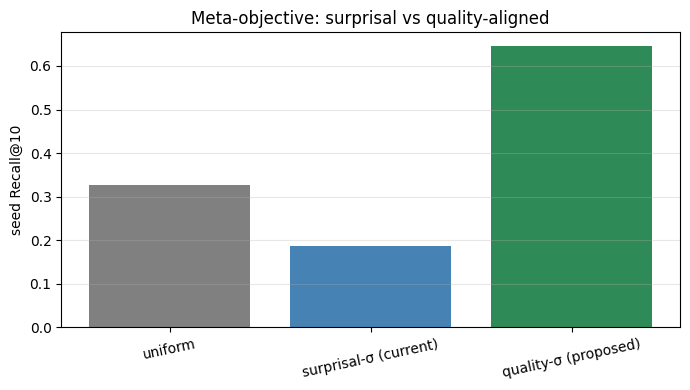

In [6]:
arm_ids = agents + ["cosine"]
arm_quality = {a: recall_at_k(router("single:"+a), 10) for a in arm_ids}
tot = sum(max(0.0,v) for v in arm_quality.values()) or 1.0
sigma_quality = {a: max(0.0,v)/tot for a,v in arm_quality.items()}
print("per-arm standalone Recall@10:", {k:round(v,3) for k,v in arm_quality.items()})
print("quality-aligned σ:", {k:round(v,3) for k,v in sigma_quality.items()})

comp = {"uniform": recall_at_k(router("uniform"),10),
        "surprisal-σ (current)": recall_at_k(router("sigma"),10),
        "quality-σ (proposed)": recall_at_k(router("sigma", sigma_quality),10)}
display(pd.Series(comp, name="Recall@10").round(3).to_frame())
plt.figure(figsize=(7,4)); bars=plt.bar(comp.keys(), comp.values(), color=["gray","steelblue","seagreen"])
plt.ylabel("seed Recall@10"); plt.title("Meta-objective: surprisal vs quality-aligned"); plt.grid(axis='y',alpha=.3)
plt.xticks(rotation=12); plt.tight_layout(); plt.show()

## Takeaways (fill in from the plots above)

- **σ learns** only when the judge emits contradictions (negative labels); with a
  coherence-only/cosine judge the surprisal signal is degenerate and σ stays
  uniform. → *A real entailment judge is a prerequisite for the meta-loop.*
- **Regret** shows whether σ beats the best fixed strategy in hindsight.
- **Fusion ablation** shows whether the learned mixture beats `uniform` and any
  single strategy — i.e. whether mixing is worth it on this data.
- **Quality-aligned σ** tests the core improvement thesis: replacing the surprisal
  proxy with a downstream-usefulness objective. If quality-σ > surprisal-σ, the
  meta-reward should be re-aligned (see `psro._meta_reward`).

**Proposed next improvements** (from the analysis): responsibility-weighted credit
(scale by proposal probability), info-gain reward (`graph.info_gain`) instead of
raw surprisal, adding TGN-backed vs Bayesian-backed scorers as *separate arms*, and
query-conditioned σ (a gate net mapping query→mixture).